# Passo 2: Como o Computador enxerga a imagem?

Excelente! Agora que capturamos a foto, precisamos entender que, para o Python, uma imagem não passa de uma **Matriz do NumPy** (uma grande tabela de números).
Neste notebook vamos:
1. Inspecionar o tamanho matemático da sua imagem.
2. Fazer um "Recorte" (Region of Interest - ROI).
3. Converter para Escala de Cinza e achar as **Bordas** dos objetos da sua bancada.

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# IMPORTANTE: Cole aqui a exata URL (com usuário e senha) que funcionou no arquivo anterior
RTSP_URL = 'rtsp://admin:@Jeff2712@10.64.0.60:554/'

cap = cv2.VideoCapture(RTSP_URL)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    print("Frame capturado com sucesso para nossos estudos!")
else:
    print("Ops, não conseguiu capturar.")

Frame capturado com sucesso para nossos estudos!


### 1. Entendendo a Matriz e fazendo um Recorte (Crop)
Quando pedimos o `.shape` da imagem, ele retorna 3 valores: `(Altura, Largura, Canais de Cor)`.

Formato matemático da imagem: (1296, 2304, 3)


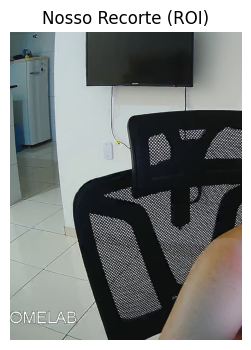

In [12]:
print(f"Formato matemático da imagem: {frame.shape}")

# Como a imagem é uma matriz matemática, podemos "recortar" um pedaço dela 
# usando fatiamento (slicing) de listas do Python.
# Vamos tentar pegar do pixel 100 até o 400 (altura) e do 200 até o 600 (largura).
# Sinta-se livre para mudar esses números e ver o que acontece!

recorte = frame_rgb[100:17700, 100:1000]

plt.figure(figsize=(6,4))
plt.imshow(recorte)
plt.title('Nosso Recorte (ROI)')
plt.axis('off')
plt.show()

### 2. Filtros e Extração de Características
Algoritmos de inteligência artificial e sensores de movimento normalmente trabalham com imagens em **Preto e Branco**, pois processar apenas 1 canal de cor (luminosidade) é 3x mais rápido do que processar RGB.

Vamos converter para escala de cinza e usar o algoritmo de **Canny**, que procura por contrastes fortes para "desenhar" as bordas dos objetos.

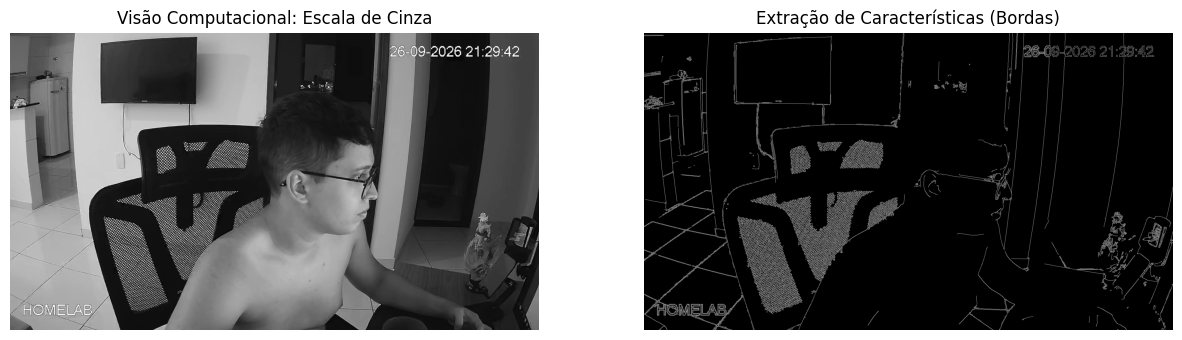

In [5]:
# 1. Converte para Cinza
frame_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# 2. Aplica o detector de bordas (Canny Edge Detection)
# Os valores 100 e 200 são os 'limiares' (thresholds). Mudanças de luz maiores que isso viram linha branca.
bordas = cv2.Canny(frame_cinza, 100, 200)

# Exibindo as duas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.imshow(frame_cinza, cmap='gray')
ax1.set_title('Visão Computacional: Escala de Cinza')
ax1.axis('off')

ax2.imshow(bordas, cmap='gray')
ax2.set_title('Extração de Características (Bordas)')
ax2.axis('off')

plt.show()